# Supplementary Figure S6: AlphaGenome splice outputs

**Purpose.** Compare the AUROC of composite and splice-specific AlphaGenome output heads.

## Reproducibility contract

- **Run from:** the repository root.
- **Input:** `data/model_scores/alphagenome_all_outputs.csv.gz` (generated by `DNA-based Models/AlphaGenome_all_outputs.ipynb`; not stored in GitHub).
- **Source:** [AlphaGenome](https://deepmind.google.com/science/alphagenome/); API access is required only for the preceding scoring notebook.
- **Outputs:** `results/tables/figure_s6_alphagenome_splice_auroc.csv` and `results/figures/figure_s6.svg`.
- **Randomness:** none.
- **Cohort:** variants selected by `ClinVarName_splice == 1` in the AlphaGenome scoring notebook.


## 1. Setup


In [1]:
from pathlib import Path
import pandas as pd

# Run this notebook from the repository root.
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODEL_SCORE_DIR = DATA_DIR / "model_scores"
RESULTS_DIR = REPO_ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
SCORED_BENCHMARK_PATH = DATA_DIR / "processed" / "clinvar_benchmark_updated.csv"
RANDOM_SEED = 42

def read_table(path, required_columns=()):
    """Read a local table and verify that required columns are present."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}. See README.md.")
    frame = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(
        path, low_memory=False, dtype={"#CHROM": str}
    )
    missing = sorted(set(required_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return frame

def validate_output_files(paths):
    """Verify that every expected output was created and is not empty."""
    for value in paths:
        path = Path(value)
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Expected output was not created: {path}")
    print(f"Validated {len(paths)} output file(s).")


FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load and validate input


In [2]:
import pandas as pd


INPUT_PATH = MODEL_SCORE_DIR / "alphagenome_all_outputs.csv.gz"
OUTPUT_COLUMNS = [
    "SPLICE_SITES_quantile_abs",
    "SPLICE_SITES_raw_abs",
    "SPLICE_SITE_USAGE_quantile_abs",
    "SPLICE_SITE_USAGE_raw_abs",
    "SpliceJunction_quantile_abs",
    "SpliceJunction_raw_abs",
    "composite_quantile_score",
    "splice_head_composite_quantile_score",
    "aggregate_splice",
]

data = read_table(INPUT_PATH, ["ClinVar_label"] + OUTPUT_COLUMNS)
print(data[OUTPUT_COLUMNS].isna().sum())
complete = data.dropna(subset=["ClinVar_label"] + OUTPUT_COLUMNS).copy()
print(f"Complete cases available for all outputs: {len(complete):,}")


SPLICE_SITES_quantile_abs               1
SPLICE_SITES_raw_abs                    1
SPLICE_SITE_USAGE_quantile_abs          1
SPLICE_SITE_USAGE_raw_abs               1
SpliceJunction_quantile_abs             2
SpliceJunction_raw_abs                  2
composite_quantile_score                0
splice_head_composite_quantile_score    1
aggregate_splice                        1
dtype: int64
Complete cases available for all outputs: 10,211


## 3. Compute output-head AUROCs


In [3]:
from sklearn.metrics import roc_auc_score

rows = [
    {
        "output": column,
        "n": len(complete),
        "auroc": roc_auc_score(complete["ClinVar_label"], complete[column]),
    }
    for column in OUTPUT_COLUMNS
]
auroc_table = pd.DataFrame(rows).sort_values("auroc", ascending=False)
auroc_table.to_csv(
    TABLE_DIR / "figure_s6_alphagenome_splice_auroc.csv",
    index=False,
)
display(auroc_table)
auroc_by_output = auroc_table.set_index("output")["auroc"]


,output,n,auroc
3,SPLICE_SITE_USAGE_raw_abs,10211,0.772814
1,SPLICE_SITES_raw_abs,10211,0.687185
2,SPLICE_SITE_USAGE_quantile_abs,10211,0.685496
8,aggregate_splice,10211,0.657056
5,SpliceJunction_raw_abs,10211,0.656996
0,SPLICE_SITES_quantile_abs,10211,0.656220
6,composite_quantile_score,10211,0.610693
7,splice_head_composite_quantile_score,10211,0.610640
4,SpliceJunction_quantile_abs,10211,0.589568


## 4. Render the manuscript figure


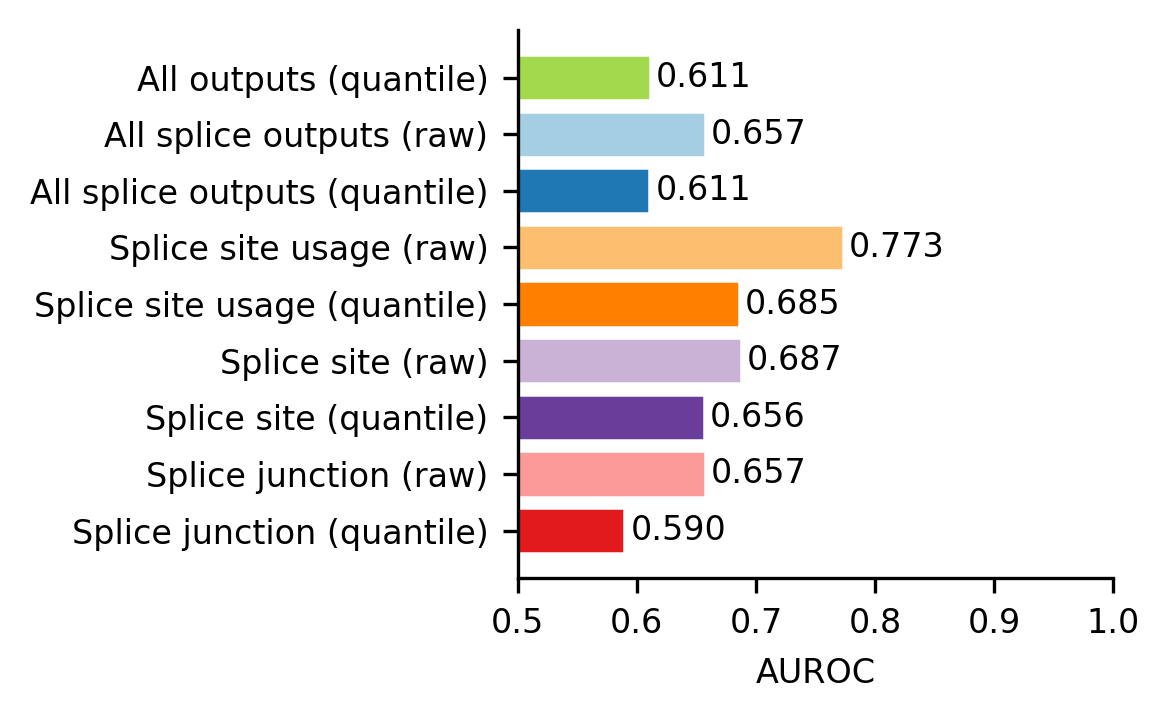

In [4]:
import matplotlib.pyplot as plt

FONT_SIZE = 8
FONT_NAME = "DejaVu Sans"
DISPLAY_NAMES = {
    "composite_quantile_score": "All outputs (quantile)",
    "aggregate_splice": "All splice outputs (raw)",
    "splice_head_composite_quantile_score": "All splice outputs (quantile)",
    "SPLICE_SITE_USAGE_raw_abs": "Splice site usage (raw)",
    "SPLICE_SITE_USAGE_quantile_abs": "Splice site usage (quantile)",
    "SPLICE_SITES_raw_abs": "Splice site (raw)",
    "SPLICE_SITES_quantile_abs": "Splice site (quantile)",
    "SpliceJunction_raw_abs": "Splice junction (raw)",
    "SpliceJunction_quantile_abs": "Splice junction (quantile)",
}
COLORS = {
    "All outputs (quantile)": "#a2d94d",
    "All splice outputs (raw)": "#a6cee3",
    "All splice outputs (quantile)": "#1f78b4",
    "Splice site usage (raw)": "#fdbf6f",
    "Splice site usage (quantile)": "#ff7f00",
    "Splice site (raw)": "#cab2d6",
    "Splice site (quantile)": "#6a3d9a",
    "Splice junction (raw)": "#fb9a99",
    "Splice junction (quantile)": "#e31a1c",
}

fig, axis = plt.subplots(figsize=(4, 2.5), dpi=300)
for column in reversed(DISPLAY_NAMES):
    label = DISPLAY_NAMES[column]
    score = auroc_by_output.loc[column]
    axis.barh(
        y=label,
        width=score,
        color=COLORS[label],
        edgecolor="white",
        linewidth=0.6,
    )
    axis.text(
        x=max(score + 0.005, 0.505),
        y=label,
        s=f"{score:.3f}",
        va="center",
        ha="left",
        fontsize=FONT_SIZE,
        fontname=FONT_NAME,
    )

axis.set_xlabel("AUROC", fontsize=FONT_SIZE, fontname=FONT_NAME)
axis.set_xlim(0.5, 1.0)
axis.spines[["top", "right"]].set_visible(False)
axis.tick_params(labelsize=FONT_SIZE)
for label in axis.get_yticklabels():
    label.set_fontname(FONT_NAME)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "figure_s6.svg", format="svg", bbox_inches="tight")
plt.show()


## 5. Validate outputs


In [5]:

validate_output_files([
    TABLE_DIR / "figure_s6_alphagenome_splice_auroc.csv",
    FIGURE_DIR / "figure_s6.svg",
])


Validated 2 output file(s).
